In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_context("notebook")

---

In [2]:
df = pd.read_csv(
    "/Users/cooper/Desktop/CAMELS-CH/clustering_results/cluster_assignments13.csv"
)

df["country"] = df["gauge_id"].str.split('_').str[0]

cluster_country_counts = df.groupby(["cluster", "country"]).size().unstack(fill_value=0)

print(cluster_country_counts)

country  CH   CL  USA
cluster              
0         2   17   13
1         3    1   98
2         3    2   21
3        19    2  103
4         0    5   40
5        52  107    3
6        11    0   56
7         0   47    0
8         3    7  163
9         1    2   69
10        2   31    0
11        0    3   26
12       39    9   70


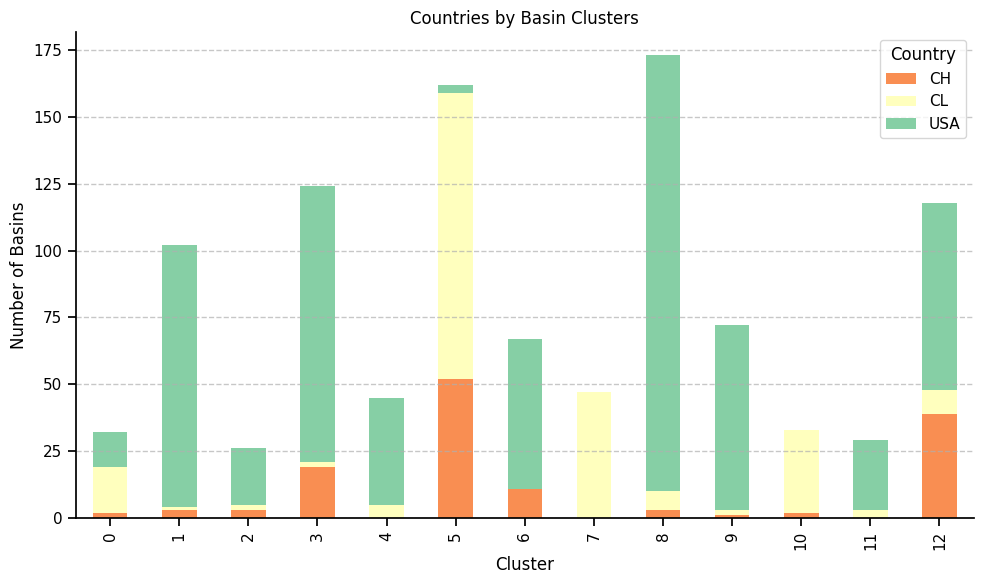

In [3]:
plt.figure(figsize=(10, 6))

palette = sns.color_palette("Spectral", len(cluster_country_counts.columns))

cluster_country_counts.plot(kind='bar', stacked=True, color=palette, ax=plt.gca())
plt.title('Countries by Basin Clusters')
plt.xlabel('Cluster')
plt.ylabel('Number of Basins')
plt.legend(title='Country')

# Add horizontal grid lines
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

sns.despine()
plt.show()

In [4]:
cluster_sizes = df['cluster'].value_counts().sort_index()

# Print key statistics
print("Cluster Sizes:")
print(cluster_sizes)
print("\nBiggest Cluster:")
print(cluster_sizes.idxmax(), "with", cluster_sizes.max(), "basins")
print("\nSmallest Cluster:")
print(cluster_sizes.idxmin(), "with", cluster_sizes.min(), "basins")

Cluster Sizes:
cluster
0      32
1     102
2      26
3     124
4      45
5     162
6      67
7      47
8     173
9      72
10     33
11     29
12    118
Name: count, dtype: int64

Biggest Cluster:
8 with 173 basins

Smallest Cluster:
2 with 26 basins


In [5]:
for country in df["country"].unique():
    path_to_basins = f"/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/{country}/post_processed/shapefiles/{country}/{country}_basin_shapes.shp"

    basins = gpd.read_file(path_to_basins)

    basins = basins.merge(
        df[["gauge_id", "cluster"]],
        left_on="gauge_id",
        right_on="gauge_id",
        how="inner",
    )

    # print(basins.head())

    # Save the merged GeoDataFrame to a new shapefile
    output_path = f"/Users/cooper/Desktop/CAMELS-CH/clustering_results/basins/clustered_basins_13_{country}.shp"\
    
    basins.to_file(output_path, driver='ESRI Shapefile')
    print(f"Saved clustered basins for {country} to {output_path}")

Saved clustered basins for CH to /Users/cooper/Desktop/CAMELS-CH/clustering_results/basins/clustered_basins_13_CH.shp
Saved clustered basins for CL to /Users/cooper/Desktop/CAMELS-CH/clustering_results/basins/clustered_basins_13_CL.shp
Saved clustered basins for USA to /Users/cooper/Desktop/CAMELS-CH/clustering_results/basins/clustered_basins_13_USA.shp


In [6]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from pyproj import Geod


def calculate_cluster_metrics(basins):
    # Reproject to a suitable UTM zone using the first basin's centroid
    centroid = basins.geometry.centroid.iloc[0]
    utm_zone = int((centroid.x + 180) / 6) + 1
    hemisphere = "north" if centroid.y >= 0 else "south"
    projected_crs = f"+proj=utm +zone={utm_zone} +{hemisphere} +ellps=WGS84 +datum=WGS84 +units=m +no_defs"

    basins_proj = basins.to_crs(projected_crs)
    centroids_proj = basins_proj.geometry.centroid

    # Extract x, y coordinates from centroids
    coords = np.array([(pt.x, pt.y) for pt in centroids_proj])

    # Compute pairwise Euclidean distances (in meters) and convert to kilometers
    distances_m = pdist(coords)
    distances_km = distances_m / 1000.0

    # Calculate basin areas in square kilometers
    basin_areas_km2 = basins_proj.geometry.area / 1_000_000

    return {"distances_km": distances_km, "basin_areas_km2": basin_areas_km2.tolist()}


# Initialize results storage
cluster_metrics = {}

# Assuming df is already defined and has the 'country', 'gauge_id', and 'cluster' columns
for country in df["country"].unique():
    path_to_basins = f"/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/{country}/post_processed/shapefiles/{country}/{country}_basin_shapes.shp"
    basins = gpd.read_file(path_to_basins)
    basins = basins.merge(
        df[["gauge_id", "cluster"]],
        on="gauge_id",
        how="inner",
    )

    # Group by cluster and calculate metrics
    for cluster in basins["cluster"].unique():
        cluster_basins = basins[basins["cluster"] == cluster]
        if len(cluster_basins) > 1:
            metrics = calculate_cluster_metrics(cluster_basins)
            cluster_metrics.setdefault(cluster, {"distances": [], "basin_areas": []})
            cluster_metrics[cluster]["distances"].extend(metrics["distances_km"])
            cluster_metrics[cluster]["basin_areas"].extend(metrics["basin_areas_km2"])

# Print summary statistics
for cluster, metrics in cluster_metrics.items():
    print(f"Cluster {cluster}:")
    print("  Distances:")
    print(f"    Mean distance: {np.mean(metrics['distances']):.2f} km")
    print(f"    Median distance: {np.median(metrics['distances']):.2f} km")
    print(f"    Max distance: {np.max(metrics['distances']):.2f} km")
    print("  Basin Areas:")
    print(f"    Mean area: {np.mean(metrics['basin_areas']):.2f} km²")
    print(f"    Median area: {np.median(metrics['basin_areas']):.2f} km²")
    print(f"    Min area: {np.min(metrics['basin_areas']):.2f} km²")
    print(f"    Max area: {np.max(metrics['basin_areas']):.2f} km²")

Cluster 5:
  Distances:
    Mean distance: 304.19 km
    Median distance: 195.26 km
    Max distance: 2639.35 km
  Basin Areas:
    Mean area: 1393.81 km²
    Median area: 482.00 km²
    Min area: 27.24 km²
    Max area: 19869.96 km²
Cluster 3:
  Distances:
    Mean distance: 801.50 km
    Median distance: 767.01 km
    Max distance: 2502.45 km
  Basin Areas:
    Mean area: 880.68 km²
    Median area: 219.47 km²
    Min area: 4.23 km²
    Max area: 14824.62 km²
Cluster 12:
  Distances:
    Mean distance: 1211.86 km
    Median distance: 416.05 km
    Max distance: 4724.88 km
  Basin Areas:
    Mean area: 745.52 km²
    Median area: 261.19 km²
    Min area: 11.77 km²
    Max area: 16793.41 km²
Cluster 2:
  Distances:
    Mean distance: 1253.95 km
    Median distance: 317.60 km
    Max distance: 3020.57 km
  Basin Areas:
    Mean area: 584.61 km²
    Median area: 254.19 km²
    Min area: 18.02 km²
    Max area: 7255.60 km²
Cluster 6:
  Distances:
    Mean distance: 468.19 km
    Median di

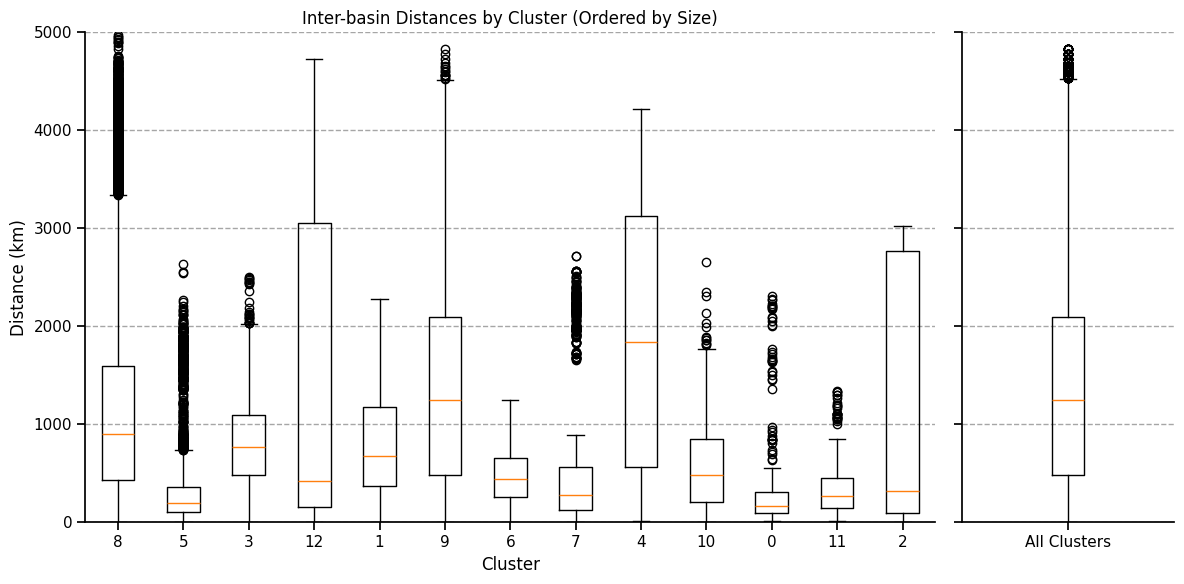

In [7]:
cluster_sizes = df["cluster"].value_counts()

# Order clusters (only those with computed distances) by cluster size (descending order)
ordered_clusters = sorted(
    [c for c in cluster_metrics.keys()], key=lambda c: cluster_sizes[c], reverse=True
)

# Extract distances in the sorted order for individual clusters
ordered_distances = [cluster_metrics[c]["distances"] for c in ordered_clusters]

# Aggregate all distances across clusters
all_distances = []
for distances in cluster_metrics.values():
    all_distances.extend(metrics["distances"])

# Create a 1x2 grid with the first plot larger than the second one using width_ratios
fig, ax = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={"width_ratios": [4, 1]})

ax[0].yaxis.grid(color='gray', linestyle='--', alpha=0.7)
ax[1].yaxis.grid(color='gray', linestyle='--', alpha=0.7)

# Plot 1: Boxplot of inter-basin distances by cluster (ordered by size)
ax[0].boxplot(ordered_distances, labels=[f"{c}" for c in ordered_clusters])
ax[0].set_ylim(0, 5000)
ax[0].set_xlabel("Cluster")
ax[0].set_ylabel("Distance (km)")
ax[0].set_title("Inter-basin Distances by Cluster (Ordered by Size)")
sns.despine(ax=ax[0])

# Plot 2: Boxplot with all clusters aggregated
ax[1].boxplot(all_distances, labels=["All Clusters"])
ax[1].set_ylim(0, 5000)
ax[1].set_ylabel("Distance (km)")

# Remove y-axis label for the second plot
ax[1].set_ylabel("")
ax[1].set_yticklabels([])

sns.despine(ax=ax[1])

plt.tight_layout()
plt.show()

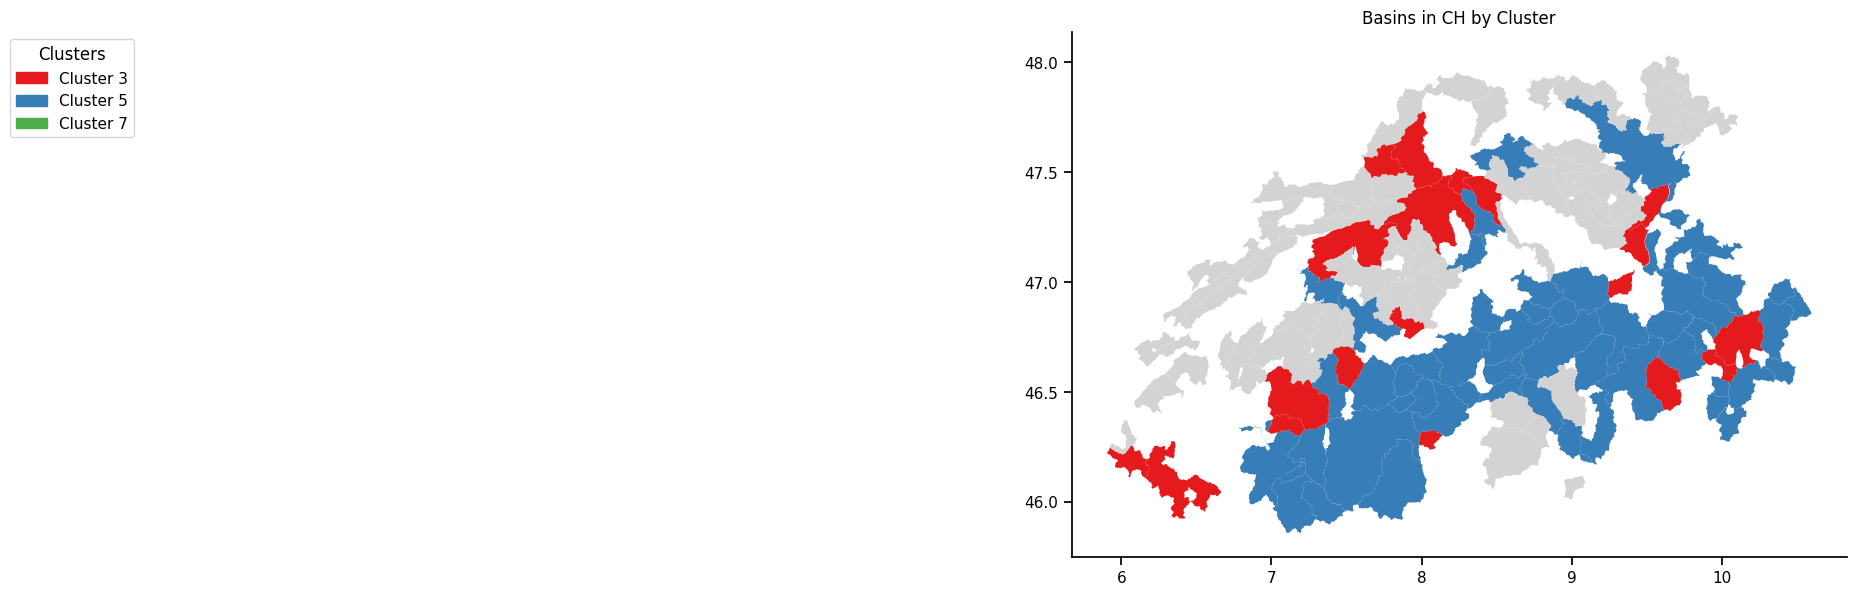

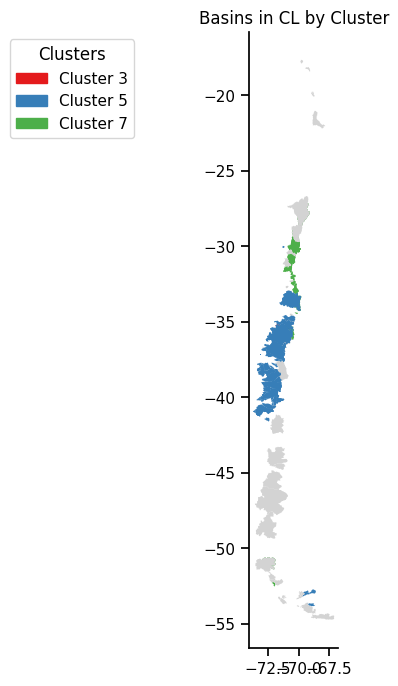

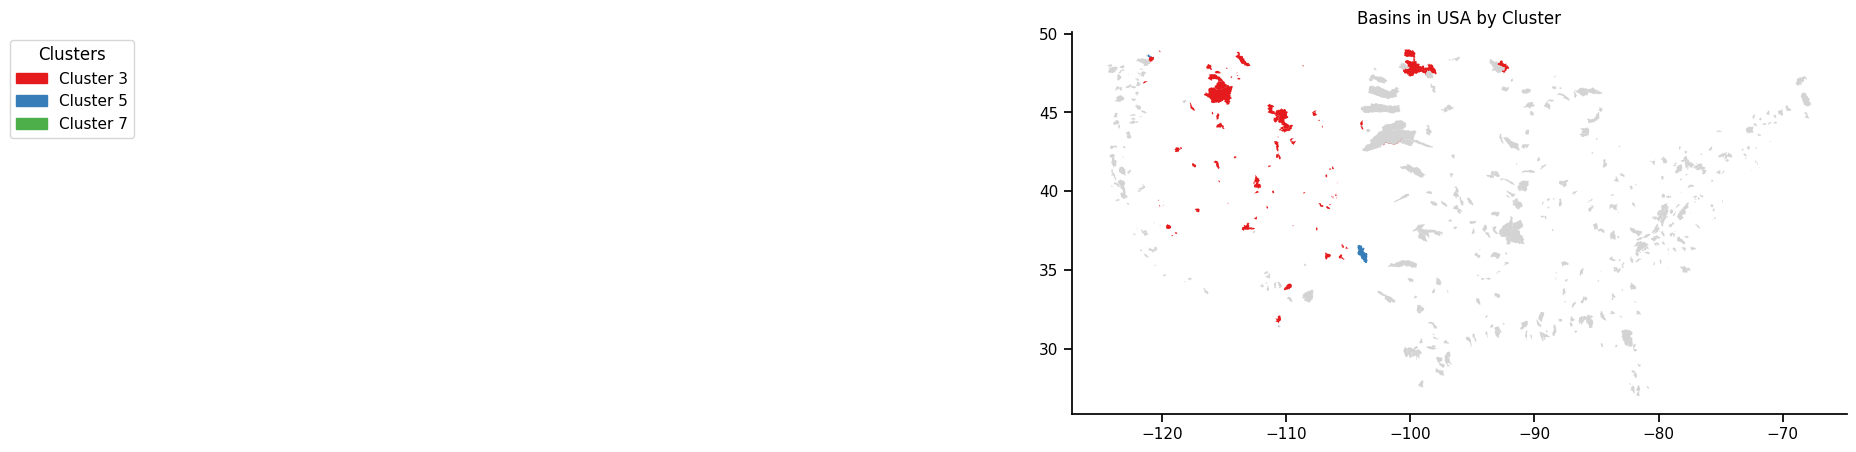

In [15]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# Define distinct colors for highlight clusters
highlight_clusters = [3, 5, 7]
highlight_colors = ['#e41a1c', '#377eb8', '#4daf4a']  # Red, Blue, Green
unique_clusters = df["cluster"].unique()
colors = {cluster: highlight_colors[highlight_clusters.index(cluster)] if cluster in highlight_clusters else 'lightgray' 
          for cluster in sorted(unique_clusters)}

# Plot the basins for each country
for country in df["country"].unique():
    path_to_basins = f"/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/{country}/post_processed/shapefiles/{country}/{country}_basin_shapes.shp"
    basins = gpd.read_file(path_to_basins)
    basins = basins.merge(
        df[["gauge_id", "cluster"]],
        on="gauge_id",
        how="inner",
    )

    # Plot the basins with manually assigned cluster colors
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    basins["color"] = basins["cluster"].map(colors)
    basins.plot(color=basins["color"], ax=ax, legend=False)

    # Create a legend for highlighted clusters
    patches = [mpatches.Patch(color=colors[cluster], label=f"Cluster {cluster}") for cluster in highlight_clusters]
    ax.legend(handles=patches, title="Clusters", loc="upper right", bbox_to_anchor=(-1.2, 1))

    ax.set_title(f"Basins in {country} by Cluster")
    sns.despine()
    plt.show()

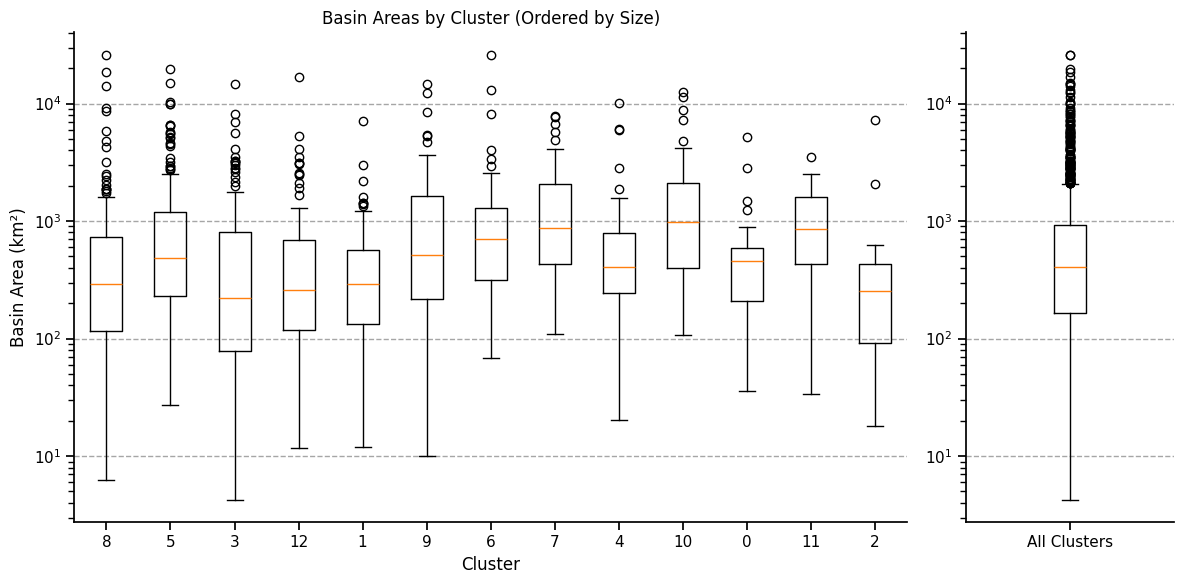

In [9]:
# Order clusters by cluster size (descending order)
ordered_clusters = sorted(
    [c for c in cluster_metrics.keys()], 
    key=lambda c: cluster_sizes[c], 
    reverse=True
)

# Extract basin areas in the sorted order for individual clusters
ordered_areas = [cluster_metrics[c]['basin_areas'] for c in ordered_clusters]

# Aggregate all basin areas across clusters
all_areas = []
for metrics in cluster_metrics.values():
    all_areas.extend(metrics['basin_areas'])

# Create a 1x2 grid with the first plot larger than the second one using width_ratios
fig, ax = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={"width_ratios": [4, 1]})

ax[0].yaxis.grid(color='gray', linestyle='--', alpha=0.7)
ax[1].yaxis.grid(color='gray', linestyle='--', alpha=0.7)

# Plot 1: Boxplot of basin areas by cluster (ordered by size)
ax[0].boxplot(ordered_areas, labels=[f"{c}" for c in ordered_clusters])
ax[0].set_xlabel("Cluster")
ax[0].set_ylabel("Basin Area (km²)")
ax[0].set_title("Basin Areas by Cluster (Ordered by Size)")
sns.despine(ax=ax[0])

# Plot 2: Boxplot with all clusters aggregated
ax[1].boxplot(all_areas, labels=["All Clusters"])
ax[1].set_ylabel("Basin Area (km²)")

# Remove y-axis label for the second plot
ax[1].set_ylabel("")
ax[1].set_yticklabels([])

# Make y axis log scale
ax[0].set_yscale('log')
ax[1].set_yscale('log')

sns.despine(ax=ax[1])
plt.tight_layout()
plt.show()

---

In [10]:
import sys
from pathlib import Path
from dataclasses import dataclass
from typing import List
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

import sys
from pathlib import Path

sys.path.append(str(Path().absolute().parent))


from clustering.preprocess_time_series import prepare_timeseries_data
from clustering.time_series_clusterer import TimeSeriesClusterer
from src.data_models.caravanify import Caravanify, CaravanifyConfig

from src.data_models.datamodule import HydroDataModule


@dataclass
class ClassificationConfig:
    """Configuration for the time series clustering process."""

    attributes_base_dir: str
    timeseries_base_dir: str

    # Output paths
    output_dir: str
    cluster_assignment_path: str
    statics_to_keep: List[str]


def get_cluster_assignments(config: ClassificationConfig) -> pd.DataFrame:
    """
    Load cluster assignments from CSV file.
    """

    cluster_assignments = pd.read_csv(config.cluster_assignment_path)

    cluster_assignments["country"] = (
        cluster_assignments["gauge_id"].str.split("_").str[0]
    )
    return cluster_assignments


def get_country_basins_from_cluster_assignments(
    country: str, config: ClassificationConfig
) -> List[str]:
    """
    Extract unique basins for a given country from cluster assignments DataFrame.
    """
    cluster_assignments = get_cluster_assignments(config)

    return (
        cluster_assignments[cluster_assignments["country"] == country]["gauge_id"]
        .unique()
        .tolist()
    )


def map_clusters_to_basins(
    static_df: pd.DataFrame, config: ClassificationConfig
) -> pd.DataFrame:
    """
    Map clusters to basins for a given country.
    """

    cluster_assignments = get_cluster_assignments(config)

    # Map gauge_id in static df to cluster in cluster assignments
    static_df["cluster"] = static_df["gauge_id"].map(
        cluster_assignments.set_index("gauge_id")["cluster"]
    )
    return static_df


def load_country_data(country: str, config: ClassificationConfig) -> pd.DataFrame:
    """
    Load and preprocess data for a country using HydroDataModule.
    Returns cleaned daily time series DataFrame.
    """
    print(f"Loading data for {country}...")

    # Get basin IDs with cluster assignments
    basin_ids = get_country_basins_from_cluster_assignments(country, config)[:10]
    
    if not basin_ids:
        print(f"Warning: No basins with cluster assignments found for {country}")
        return pd.DataFrame()

    # Configure Caravanify
    caravan_config = CaravanifyConfig(
        attributes_dir=f"{config.attributes_base_dir}/{country}/post_processed/attributes",
        timeseries_dir=f"{config.timeseries_base_dir}/{country}/post_processed/timeseries/csv",
        gauge_id_prefix=country,
        use_hydroatlas_attributes=True,
        use_caravan_attributes=True,
        use_other_attributes=True,
    )

    caravan = Caravanify(caravan_config)
    
    # Load stations
    caravan.load_stations(basin_ids)
    static_df = caravan.get_static_attributes()
    
    if static_df.empty:
        print(f"Warning: No static attributes found for {country}")
        return pd.DataFrame()
    
    # Ensure we have all the required columns
    missing_cols = [col for col in config.statics_to_keep if col not in static_df.columns]
    if missing_cols:
        print(f"Warning: Missing columns in static data for {country}: {missing_cols}")
        # Add missing columns with NaN values
        for col in missing_cols:
            static_df[col] = np.nan

    # Get only the columns we want to keep
    static_df = static_df[config.statics_to_keep]
    
    # Add cluster assignments - this will add the cluster column
    labeled_df = map_clusters_to_basins(static_df, config)
    
    # Filter rows with missing cluster
    result_df = labeled_df.dropna(subset=["cluster"])
    
    print(f"  Processed {len(result_df)} basins with valid data and cluster assignments for {country}")
    
    return result_df

In [11]:
config = ClassificationConfig(
    attributes_base_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY",
    timeseries_base_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY",
    output_dir="/Users/cooper/Desktop/CAMELS-CH/clustering_results",
    cluster_assignment_path="/Users/cooper/Desktop/CAMELS-CH/clustering_results/cluster_assignments12.csv",
    statics_to_keep=[
        "gauge_id",
        "area",
        "gauge_lat",
        "gauge_lon",
        "frac_snow",
        "p_mean",
        "pet_mean_ERA5_LAND",
        "seasonality_ERA5_LAND",
        "aridity_ERA5_LAND",
        "slp_dg_sav",
        "high_prec_dur",
        "high_prec_freq",
        "low_prec_dur",
        "low_prec_freq",
        "cmi_ix_syr",
        "for_pc_sse",
        "glc_cl_smj",
        "rdd_mk_sav",
        # "cluster",
    ]
)

country = "CH"

all_data = []
for country in ["CH", "CL", "USA"]:
    country_data = load_country_data(country, config)
    all_data.append(country_data)

combined_data = pd.concat(all_data, ignore_index=True)

Loading data for CH...
  Processed 10 basins with valid data and cluster assignments for CH
Loading data for CL...
  Processed 10 basins with valid data and cluster assignments for CL
Loading data for USA...
  Processed 10 basins with valid data and cluster assignments for USA


In [12]:
combined_data.tail()

,gauge_id,area,gauge_lat,gauge_lon,frac_snow,p_mean,pet_mean_ERA5_LAND,seasonality_ERA5_LAND,aridity_ERA5_LAND,slp_dg_sav,high_prec_dur,high_prec_freq,low_prec_dur,low_prec_freq,cmi_ix_syr,for_pc_sse,glc_cl_smj,rdd_mk_sav,cluster
25,USA_01052500,395.444910,44.87739,-71.05749,0.368406,3.402069,10.642907,0.922056,3.128363,88.993129,1.078040,0.040657,2.515905,0.519713,33.823513,99.899693,2,12.244044,2
26,USA_01054200,180.835783,44.39044,-70.97964,0.374272,3.664167,10.999369,0.837113,3.001874,124.000000,1.104073,0.050103,2.938824,0.588569,39.000000,95.000000,2,87.000000,8
27,USA_01055000,250.426117,44.64275,-70.58878,0.386999,3.177602,11.824328,0.679333,3.721149,88.614819,1.088496,0.050513,3.126644,0.618480,30.731477,98.673148,2,153.296374,8
28,USA_01057000,197.428264,44.30399,-70.53968,0.310281,3.269270,13.216374,0.558657,4.042607,67.212435,1.104278,0.056537,3.383925,0.645517,23.748367,100.000000,2,262.581663,8
29,USA_01073000,32.107003,43.14870,-70.96506,0.244600,3.193947,15.945499,0.304430,4.992413,17.241375,1.101828,0.057769,3.412078,0.657426,12.386823,89.984408,2,1189.829990,8


In [13]:
X = combined_data.drop(columns=["gauge_id", "cluster"])
X

,area,gauge_lat,gauge_lon,frac_snow,p_mean,pet_mean_ERA5_LAND,seasonality_ERA5_LAND,aridity_ERA5_LAND,slp_dg_sav,high_prec_dur,high_prec_freq,low_prec_dur,low_prec_freq,cmi_ix_syr,for_pc_sse,glc_cl_smj,rdd_mk_sav
0,701.274189,46.349564,6.888617,0.386329,4.954752,4.953492,1.287266,0.999746,248.671068,1.134021,0.030118,3.062444,0.466630,47.631952,73.006060,2,751.665744
1,1566.180595,46.219089,7.357908,0.479000,4.197982,2.349016,1.191149,0.559558,247.628593,1.223587,0.034089,2.981481,0.462865,64.791664,49.421850,14,529.042694
2,811.489711,47.482537,8.194880,0.000000,3.908174,3.081813,0.921123,0.788556,65.255587,1.114286,0.029365,3.121670,0.481210,29.638318,66.005975,2,2921.137724
3,229.895078,47.421030,8.271271,0.000000,3.691103,2.811606,1.008329,0.761725,47.522328,1.146226,0.033267,3.228032,0.502909,31.597222,62.344257,2,3320.327415
4,554.489324,46.745743,8.092031,0.420558,5.468537,2.529632,0.638263,0.462579,272.113992,1.206490,0.027996,2.905288,0.413649,74.665404,36.611995,14,246.021452
5,203.514362,46.193768,9.009287,0.150551,4.342311,5.792497,1.211849,1.333966,288.983838,1.373796,0.048806,3.344170,0.528099,52.579772,90.727568,4,506.511779
6,357.664011,46.125656,7.091281,0.387402,4.642949,3.244399,1.196280,0.698780,228.463087,1.143204,0.032240,3.070796,0.475050,50.229439,59.618420,14,729.883493
7,747.151080,46.775807,9.206352,0.404815,5.086900,4.005412,1.039148,0.787398,247.762449,1.210269,0.033883,2.904090,0.422822,72.083132,51.920589,14,241.077256
8,415.350392,46.835913,6.936070,0.081907,3.755151,2.903590,1.134510,0.773229,60.175334,1.152083,0.037853,3.315812,0.522486,23.557066,29.588280,13,1515.966580
9,404.675845,47.596523,8.681980,0.000000,3.424328,3.161138,1.064023,0.923141,37.380334,1.166667,0.034020,3.252155,0.516462,23.511044,48.236422,2,2266.294833
